In [ ]:
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib.lines import Line2D
cmap = plt.get_cmap('Greys_r')
white_cmap = mpl.colors.LinearSegmentedColormap.from_list('white_greys', cmap(np.linspace(0.5, 1.0, 256)))

%matplotlib widget

In [ ]:
# Import rotation model functions
from rotation_model_numpy import (
    calc_v_dev,
    v_rot_simple,
    v_rot_univ,
    v_rot_linear,
    v_rot_poly,
)

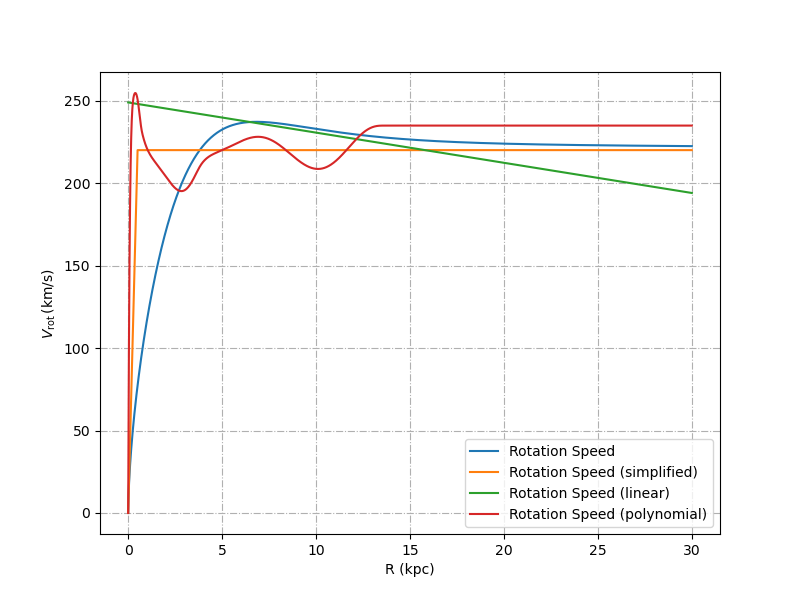

In [3]:
# Compare different rotation curve models

r = np.arange(0, 30, 0.01)
Vr = v_rot_univ(r)
Vr_simple = v_rot_simple(r)
Vr_linear = v_rot_linear(r)
Vr_poly = v_rot_poly(r)

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(r, Vr, label="Rotation Speed")
plt.plot(r, Vr_simple, label="Rotation Speed (simplified)")
plt.plot(r, Vr_linear, label="Rotation Speed (linear)")
plt.plot(r, Vr_poly, label="Rotation Speed (polynomial)")
plt.xlabel("R (kpc)")
plt.ylabel(r"$V_{\mathrm{rot}}\,\mathrm{(km/s)}$")
plt.legend()
plt.grid(ls="-.")
plt.show()

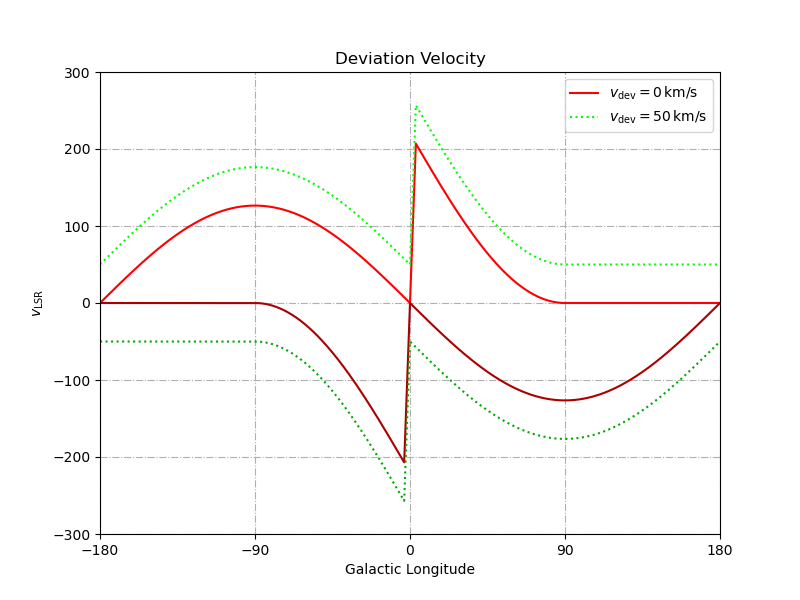

In [ ]:
# Deviation Velocity Example

l_array = np.arange(-180, 180.1, 0.1)
v_max_arr1, v_min_arr1 = calc_v_dev(l_array, b=0, model="simple", v_dev=0)
v_max_arr2, v_min_arr2 = calc_v_dev(l_array, b=0, model="simple", v_dev=50)

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(
    l_array,
    v_max_arr1,
    ls="-",
    label=r"$v_{\mathrm{dev}}=0\,\mathrm{km/s}$",
    color="#FF0000",
)
plt.plot(l_array, v_min_arr1, ls="-", color="#AA0000")
plt.plot(
    l_array,
    v_max_arr2,
    ls=":",
    label=r"$v_{\mathrm{dev}}=50\,\mathrm{km/s}$",
    color="#00FF00",
)
plt.plot(l_array, v_min_arr2, ls=":", color="#00AA00")
plt.xticks(np.arange(-180, 270, 90))
plt.yticks(np.arange(-300, 400, 100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$v_{\mathrm{LSR}}$")
plt.xlim(-180, 180)
plt.ylim(-300, 300)
plt.grid(ls="-.")
plt.legend()
plt.title("Deviation Velocity")
plt.show()

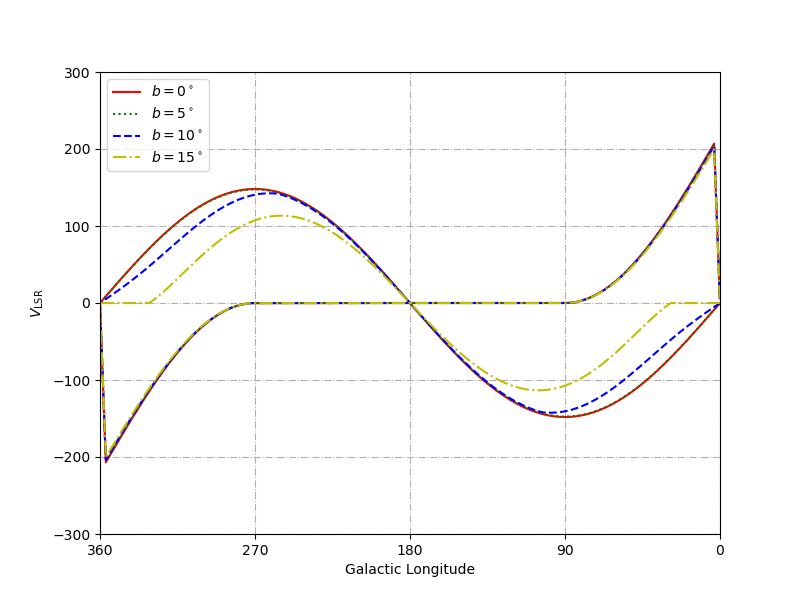

In [ ]:
# Galactic Longitude vs. V_max and V_min for b=0, 5, 10, 15
# Using Simple Rotation Curve Model

l_array = np.arange(0.1, 360.1, 0.1)

v_max_arr1, v_min_arr1 = calc_v_dev(l_array, b=0, h=4, r_gal=26, model="simple")
v_max_arr2, v_min_arr2 = calc_v_dev(l_array, b=5, h=4, r_gal=26, model="simple")
v_max_arr3, v_min_arr3 = calc_v_dev(l_array, b=10, h=4, r_gal=26, model="simple")
v_max_arr4, v_min_arr4 = calc_v_dev(l_array, b=15, h=4, r_gal=26, model="simple")

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="r")
plt.plot(l_array, v_min_arr1, ls="-", color="r")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=5^\circ$", color="g")
plt.plot(l_array, v_min_arr2, ls=":", color="g")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=10^\circ$", color="b")
plt.plot(l_array, v_min_arr3, ls="--", color="b")
plt.plot(l_array, v_max_arr4, ls="-.", label=r"$b=15^\circ$", color="y")
plt.plot(l_array, v_min_arr4, ls="-.", color="y")

plt.xticks(np.arange(0, 450, 90))
plt.yticks(np.arange(-300, 400, 100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$V_{\mathrm{LSR}}$")
plt.xlim(0, 360)
plt.ylim(-300, 300)
plt.grid(ls="-.")
plt.legend(loc="upper left")
plt.gca().invert_xaxis()
plt.show()

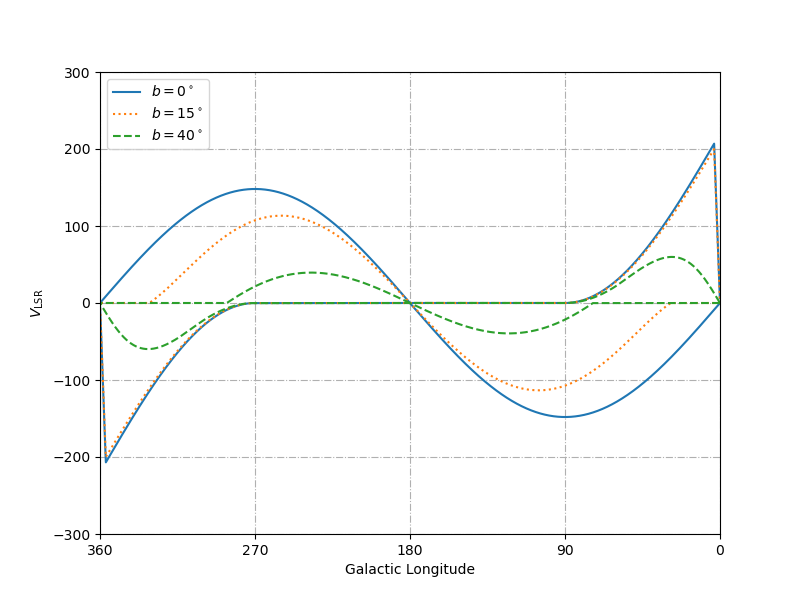

In [ ]:
# Galactic Longitude vs. V_max and V_min for b=0, 15, 40
# Using Simple Rotation Curve Model
# Same as Fig.1 in (Wakker 1991)

l_array = np.arange(0.1, 360, 0.1)

v_max_arr1, v_min_arr1 = calc_v_dev(l_array, b=0, h=4, r_gal=26, model="simple")
v_max_arr2, v_min_arr2 = calc_v_dev(l_array, b=15, h=4, r_gal=26, model="simple")
v_max_arr3, v_min_arr3 = calc_v_dev(l_array, b=40, h=4, r_gal=26, model="simple")

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="#1f77b4")
plt.plot(l_array, v_min_arr1, ls="-", color="#1f77b4")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=15^\circ$", color="#ff7f0e")
plt.plot(l_array, v_min_arr2, ls=":", color="#ff7f0e")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=40^\circ$", color="#2ca02c")
plt.plot(l_array, v_min_arr3, ls="--", color="#2ca02c")

plt.xticks(np.arange(0, 450, 90))
plt.yticks(np.arange(-300, 400, 100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$V_{\mathrm{LSR}}$")
plt.xlim(0, 360)
plt.ylim(-300, 300)
plt.grid(ls="-.")
plt.legend(loc="upper left")
plt.gca().invert_xaxis()
plt.show()

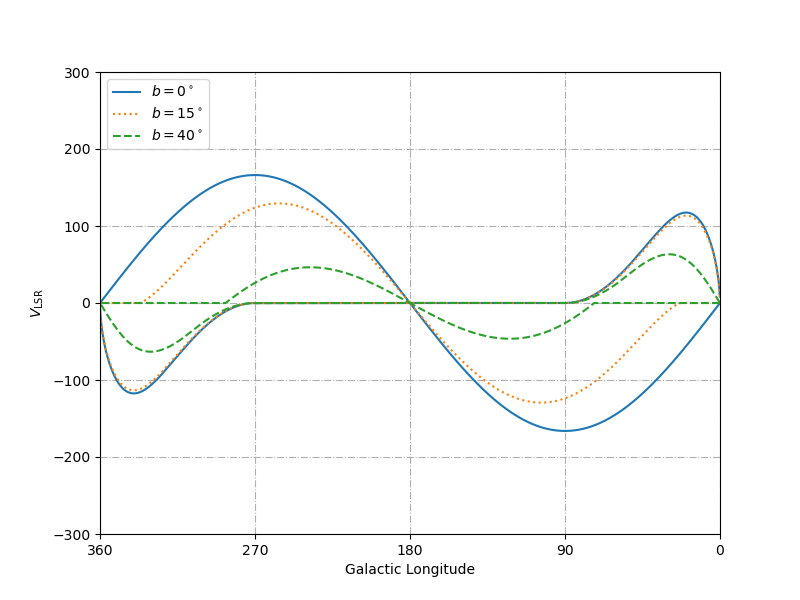

In [ ]:
# Galactic Longitude vs. V_max and V_min for b=0, 15, 40
# Using Universal Rotation Curve Model

l_array = np.arange(0.1, 360, 0.1)

v_max_arr1, v_min_arr1 = calc_v_dev(l_array, b=0, h=4, r_gal=26, model="univ")
v_max_arr2, v_min_arr2 = calc_v_dev(l_array, b=15, h=4, r_gal=26, model="univ")
v_max_arr3, v_min_arr3 = calc_v_dev(l_array, b=40, h=4, r_gal=26, model="univ")

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="#1f77b4")
plt.plot(l_array, v_min_arr1, ls="-", color="#1f77b4")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=15^\circ$", color="#ff7f0e")
plt.plot(l_array, v_min_arr2, ls=":", color="#ff7f0e")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=40^\circ$", color="#2ca02c")
plt.plot(l_array, v_min_arr3, ls="--", color="#2ca02c")

plt.xticks(np.arange(0, 450, 90))
plt.yticks(np.arange(-300, 400, 100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$V_{\mathrm{LSR}}$")
plt.xlim(0, 360)
plt.ylim(-300, 300)
plt.grid(ls="-.")
plt.legend(loc="upper left")
plt.gca().invert_xaxis()
plt.show()

/tmp/ipykernel_19359/3946597721.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 6))


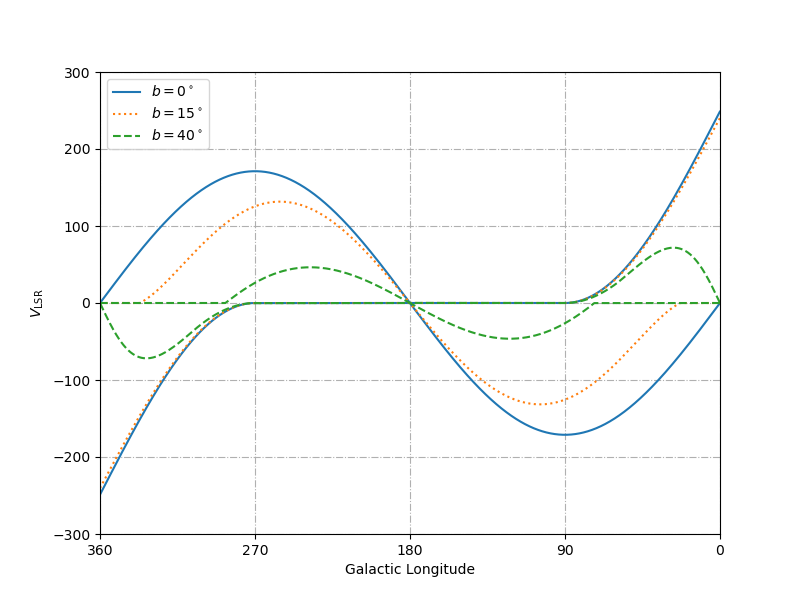

In [26]:
# Galactic Longitude vs. V_max and V_min for b=0, 15, 40
# Using Linear Rotation Curve Model

l_array = np.arange(0.1, 360, 0.1)

v_max_arr1, v_min_arr1 = calc_v_dev(l_array, b=0, h=4, r_gal=26, model="linear")
v_max_arr2, v_min_arr2 = calc_v_dev(l_array, b=15, h=4, r_gal=26, model="linear")
v_max_arr3, v_min_arr3 = calc_v_dev(l_array, b=40, h=4, r_gal=26, model="linear")

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="#1f77b4")
plt.plot(l_array, v_min_arr1, ls="-", color="#1f77b4")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=15^\circ$", color="#ff7f0e")
plt.plot(l_array, v_min_arr2, ls=":", color="#ff7f0e")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=40^\circ$", color="#2ca02c")
plt.plot(l_array, v_min_arr3, ls="--", color="#2ca02c")

plt.xticks(np.arange(0, 450, 90))
plt.yticks(np.arange(-300, 400, 100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$V_{\mathrm{LSR}}$")
plt.xlim(0, 360)
plt.ylim(-300, 300)
plt.grid(ls="-.")
plt.legend(loc="upper left")
plt.gca().invert_xaxis()
plt.show()

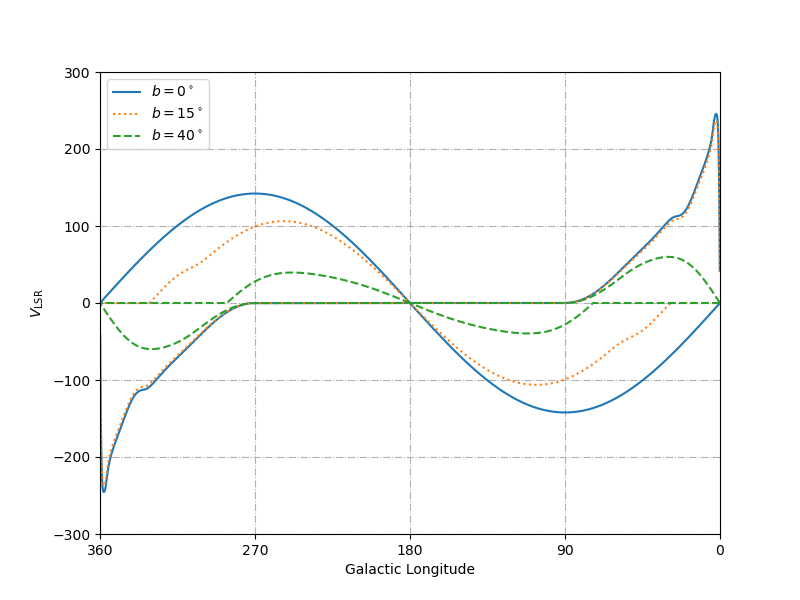

In [10]:
# Galactic Longitude vs. V_max and V_min for b=0, 15, 40
# Using Polynomial Curve Model

l_array = np.arange(0.1, 360, 0.1)

v_max_arr1, v_min_arr1 = calc_v_dev(l_array, b=0, h=4, r_gal=26, model="poly")
v_max_arr2, v_min_arr2 = calc_v_dev(l_array, b=15, h=4, r_gal=26, model="poly")
v_max_arr3, v_min_arr3 = calc_v_dev(l_array, b=40, h=4, r_gal=26, model="poly")

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="#1f77b4")
plt.plot(l_array, v_min_arr1, ls="-", color="#1f77b4")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=15^\circ$", color="#ff7f0e")
plt.plot(l_array, v_min_arr2, ls=":", color="#ff7f0e")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=40^\circ$", color="#2ca02c")
plt.plot(l_array, v_min_arr3, ls="--", color="#2ca02c")

plt.xticks(np.arange(0, 450, 90))
plt.yticks(np.arange(-300, 400, 100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$V_{\mathrm{LSR}}$")
plt.xlim(0, 360)
plt.ylim(-300, 300)
plt.grid(ls="-.")
plt.legend(loc="upper left")
plt.gca().invert_xaxis()
plt.show()

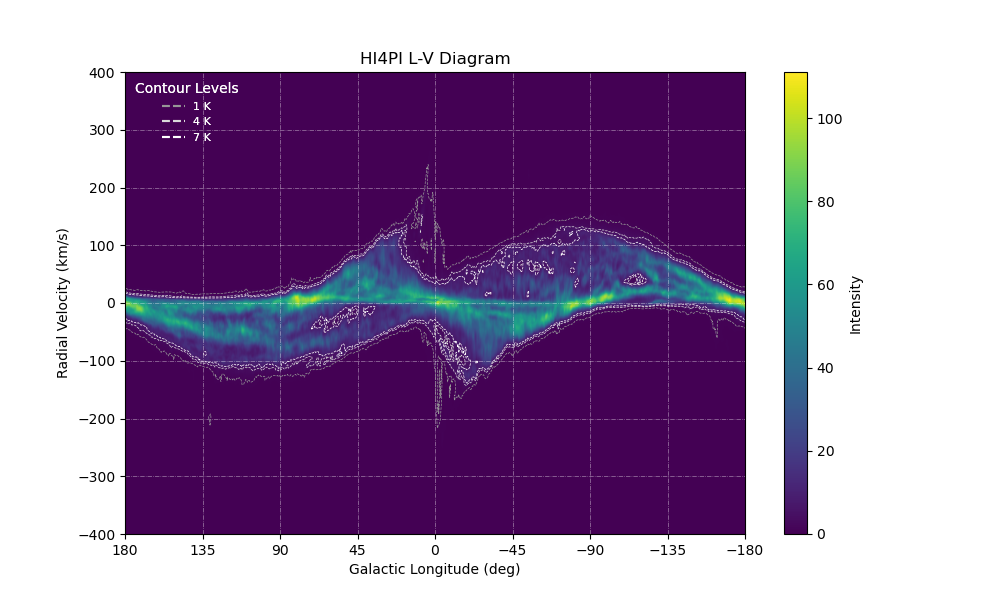

In [11]:
# HI4PI L-V Diagram

hdul = fits.open("./HI4PI_Galatic_LV.fits")

header = hdul[0].header
data = hdul[0].data
wcs = WCS(header)

ny, nx = data.shape

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    data,
    origin="lower",
    aspect="auto",
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],  # l_min
        wcs.pixel_to_world_values(nx - 1, 0)[0],  # l_max
        wcs.pixel_to_world_values(0, 0)[1] / 1000,  # v_min
        wcs.pixel_to_world_values(0, ny - 1)[1] / 1000,  # v_max
    ],
    norm=PowerNorm(gamma=1),  # 使用线性归一化
    cmap="viridis",  # 使用viridis色图
)

# 绘制等高线 - 使用color参数直接指定颜色
# 先计算每个级别的颜色
contour_levels = np.arange(1, 10, 3)
level_norm = (contour_levels - np.min(contour_levels)) / (
    np.max(contour_levels) - np.min(contour_levels)
)
level_colors = [white_cmap(val) for val in level_norm]

# 绘制等高线，指定颜色
contours = ax.contour(
    data,
    origin="lower",
    levels=contour_levels,
    colors=level_colors,  # 直接指定颜色列表
    linewidths=0.5,
    linestyles="dashed",
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],  # l_min
        wcs.pixel_to_world_values(nx - 1, 0)[0],  # l_max
        wcs.pixel_to_world_values(0, 0)[1] / 1000,  # v_min
        wcs.pixel_to_world_values(0, ny - 1)[1] / 1000,  # v_max
    ],
)

# 创建图例元素，使用相同的颜色
legend_elements = []
for level, color in zip(contour_levels, level_colors):
    legend_elements.append(
        Line2D([0], [0], color=color, lw=1.5, linestyle="dashed", label=f"{level} K")
    )

# 添加图例
legend1 = ax.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=8,
    labelcolor="white",
    framealpha=0.0,
    edgecolor="white",
    title="Contour Levels",
    handlelength=2,
)
legend1.get_title().set_color("white")
ax.add_artist(legend1)

ax.set_xlabel("Galactic Longitude (deg)")
ax.set_ylabel("Radial Velocity (km/s)")
plt.colorbar(im, ax=ax, label="Intensity")
plt.title("HI4PI L-V Diagram")

# 设置网格
ax.grid(ls="-.", color="white", alpha=0.5, linewidth=0.5)

# 设置网格线的位置
# 横坐标：-180到180，每45一个
ax.set_xticks(np.arange(-180, 181, 45))
# 纵坐标：-400到400，每100一个
ax.set_yticks(np.arange(-400, 401, 100))

# 设置坐标轴范围（确保显示完整的网格）
ax.set_xlim(-180, 180)
ax.set_ylim(-400, 400)
ax.invert_xaxis()

plt.show()

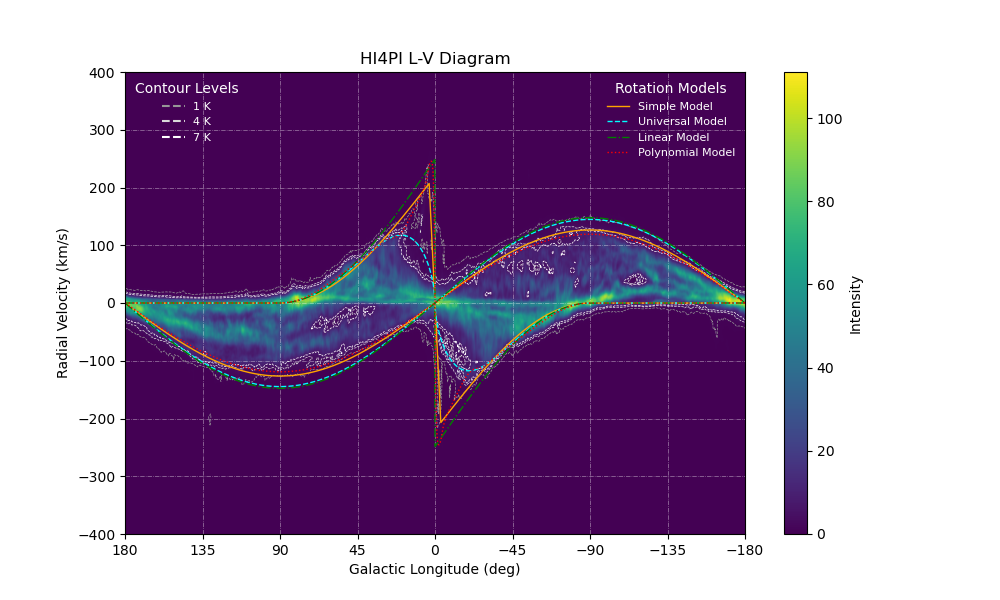

In [17]:
# Galaxy Rotation Model vs HI4PI L-V Diagram
from matplotlib.lines import Line2D

cmap = plt.get_cmap("Greys_r")
white_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "white_greys", cmap(np.linspace(0.5, 1.0, 256))
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    data,
    origin="lower",
    aspect="auto",
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],  # l_min
        wcs.pixel_to_world_values(nx - 1, 0)[0],  # l_max
        wcs.pixel_to_world_values(0, 0)[1] / 1000,  # v_min
        wcs.pixel_to_world_values(0, ny - 1)[1] / 1000,  # v_max
    ],
    norm=PowerNorm(gamma=1),  # 使用线性归一化
    cmap="viridis",  # 使用viridis色图
)

# 绘制等高线 - 使用color参数直接指定颜色
# 先计算每个级别的颜色
contour_levels = np.arange(1, 10, 3)
level_norm = (contour_levels - np.min(contour_levels)) / (
    np.max(contour_levels) - np.min(contour_levels)
)
level_colors = [white_cmap(val) for val in level_norm]

# 绘制等高线，指定颜色
contours = ax.contour(
    data,
    origin="lower",
    levels=contour_levels,
    colors=level_colors,  # 直接指定颜色列表
    linewidths=0.5,
    linestyles="dashed",
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],  # l_min
        wcs.pixel_to_world_values(nx - 1, 0)[0],  # l_max
        wcs.pixel_to_world_values(0, 0)[1] / 1000,  # v_min
        wcs.pixel_to_world_values(0, ny - 1)[1] / 1000,  # v_max
    ],
)

# 创建图例元素，使用相同的颜色
legend_elements = []
for level, color in zip(contour_levels, level_colors):
    legend_elements.append(
        Line2D([0], [0], color=color, lw=1.5, linestyle="dashed", label=f"{level} K")
    )

# 添加图例
legend1 = ax.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=8,
    labelcolor="white",
    framealpha=0.0,
    edgecolor="white",
    title="Contour Levels",
    handlelength=2,
)
legend1.get_title().set_color("white")
ax.add_artist(legend1)

ax.grid()
ax.set_xlabel("Galactic Longitude (deg)")
ax.set_ylabel("Radial Velocity (km/s)")
plt.colorbar(im, ax=ax, label="Intensity")
plt.title("HI4PI L-V Diagram")

# 画L-V图
l_array = np.arange(-179.9, 180, 0.1)
v_max_arr1, v_min_arr1 = calc_v_dev(l_array, b=0, h=5, r_gal=20, model="simple")
v_max_arr2, v_min_arr2 = calc_v_dev(l_array, b=0, h=5, r_gal=20, model="univ")
v_max_arr3, v_min_arr3 = calc_v_dev(l_array, b=0, h=5, r_gal=20, model="linear")
v_max_arr4, v_min_arr4 = calc_v_dev(l_array, b=0, h=5, r_gal=20, model="poly")


ax.plot(l_array, v_max_arr1, color="orange", linewidth=1, label="Simple Model")
ax.plot(l_array, v_min_arr1, color="orange", linewidth=1)

ax.plot(l_array, v_max_arr2, color="cyan", ls="--", linewidth=1, label="Universal Model")
ax.plot(l_array, v_min_arr2, color="cyan", ls="--", linewidth=1)

ax.plot(l_array, v_max_arr3, color="green", ls="-.", linewidth=1, label="Linear Model")
ax.plot(l_array, v_min_arr3, color="green", ls="-.", linewidth=1)

ax.plot(l_array, v_max_arr4, color="red", ls=":", linewidth=1, label="Polynomial Model")
ax.plot(l_array, v_min_arr4, color="red", ls=":", linewidth=1)

legend2 = ax.legend(
    loc="upper right",
    fontsize=8,
    labelcolor="white",
    framealpha=0.0,
    edgecolor="white",
    title="Rotation Models",
)
legend2.get_title().set_color("white")

# 设置网格
ax.grid(ls="-.", color="white", alpha=0.5, linewidth=0.5)

# 设置网格线的位置
# 横坐标：-180到180，每45一个
ax.set_xticks(np.arange(-180, 181, 45))
# 纵坐标：-400到400，每100一个
ax.set_yticks(np.arange(-400, 401, 100))

# 设置坐标轴范围（确保显示完整的网格）
ax.set_xlim(-180, 180)
ax.set_ylim(-400, 400)
ax.invert_xaxis()

plt.show()

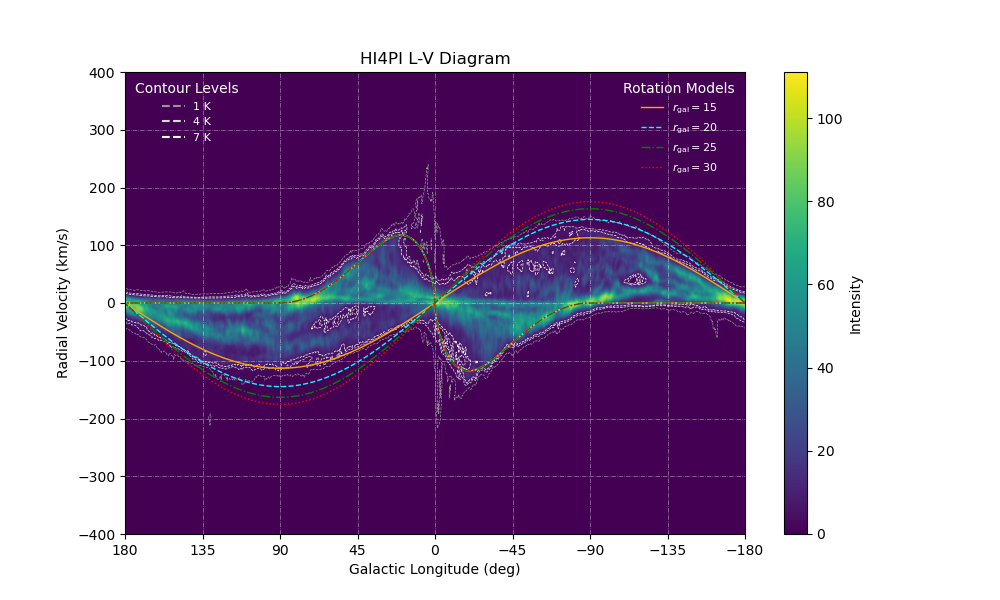

In [16]:
# Galaxy Rotation Model vs HI4PI L-V Diagram
from matplotlib.lines import Line2D

cmap = plt.get_cmap("Greys_r")
white_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "white_greys", cmap(np.linspace(0.5, 1.0, 256))
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    data,
    origin="lower",
    aspect="auto",
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],  # l_min
        wcs.pixel_to_world_values(nx - 1, 0)[0],  # l_max
        wcs.pixel_to_world_values(0, 0)[1] / 1000,  # v_min
        wcs.pixel_to_world_values(0, ny - 1)[1] / 1000,  # v_max
    ],
    norm=PowerNorm(gamma=1),  # 使用线性归一化
    cmap="viridis",  # 使用viridis色图
)

# 绘制等高线 - 使用color参数直接指定颜色
# 先计算每个级别的颜色
contour_levels = np.arange(1, 10, 3)
level_norm = (contour_levels - np.min(contour_levels)) / (
    np.max(contour_levels) - np.min(contour_levels)
)
level_colors = [white_cmap(val) for val in level_norm]

# 绘制等高线，指定颜色
contours = ax.contour(
    data,
    origin="lower",
    levels=contour_levels,
    colors=level_colors,  # 直接指定颜色列表
    linewidths=0.5,
    linestyles="dashed",
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],  # l_min
        wcs.pixel_to_world_values(nx - 1, 0)[0],  # l_max
        wcs.pixel_to_world_values(0, 0)[1] / 1000,  # v_min
        wcs.pixel_to_world_values(0, ny - 1)[1] / 1000,  # v_max
    ],
)

# 创建图例元素，使用相同的颜色
legend_elements = []
for level, color in zip(contour_levels, level_colors):
    legend_elements.append(
        Line2D([0], [0], color=color, lw=1.5, linestyle="dashed", label=f"{level} K")
    )

# 添加图例
legend1 = ax.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=8,
    labelcolor="white",
    framealpha=0.0,
    edgecolor="white",
    title="Contour Levels",
    handlelength=2,
)
legend1.get_title().set_color("white")
ax.add_artist(legend1)

ax.set_xlabel("Galactic Longitude (deg)")
ax.set_ylabel("Radial Velocity (km/s)")
plt.colorbar(im, ax=ax, label="Intensity")
plt.title("HI4PI L-V Diagram")

# 画L-V图
l_array = np.arange(-179.9, 180, 0.1)
v_max_arr1, v_min_arr1 = calc_v_dev(l_array, b=0, h=5, r_gal=15, model="univ")
v_max_arr2, v_min_arr2 = calc_v_dev(l_array, b=0, h=5, r_gal=20, model="univ")
v_max_arr3, v_min_arr3 = calc_v_dev(l_array, b=0, h=5, r_gal=25, model="univ")
v_max_arr4, v_min_arr4 = calc_v_dev(l_array, b=0, h=5, r_gal=30, model="univ")

ax.plot(l_array, v_max_arr1, color="orange", linewidth=1, label=r"$r_{\mathrm{gal}}=15$")
ax.plot(l_array, v_min_arr1, color="orange", linewidth=1)

ax.plot(l_array, v_max_arr2, color="cyan", ls="--", linewidth=1, label=r"$r_{\mathrm{gal}}=20$")
ax.plot(l_array, v_min_arr2, color="cyan", ls="--", linewidth=1)

ax.plot(l_array, v_max_arr3, color="green", ls="-.", linewidth=1, label=r"$r_{\mathrm{gal}}=25$")
ax.plot(l_array, v_min_arr3, color="green", ls="-.", linewidth=1)

ax.plot(l_array, v_max_arr4, color="red", ls=":", linewidth=1, label=r"$r_{\mathrm{gal}}=30$")
ax.plot(l_array, v_min_arr4, color="red", ls=":", linewidth=1)

legend2 = ax.legend(
    loc="upper right",
    fontsize=8,
    labelcolor="white",
    framealpha=0.0,
    edgecolor="white",
    title="Rotation Models",
)
legend2.get_title().set_color("white")

# 设置网格
ax.grid(ls="-.", color="white", alpha=0.5, linewidth=0.5)

# 设置网格线的位置
# 横坐标：-180到180，每45一个
ax.set_xticks(np.arange(-180, 181, 45))
# 纵坐标：-400到400，每100一个
ax.set_yticks(np.arange(-400, 401, 100))

# 设置坐标轴范围（确保显示完整的网格）
ax.set_xlim(-180, 180)
ax.set_ylim(-400, 400)
ax.invert_xaxis()

plt.show()

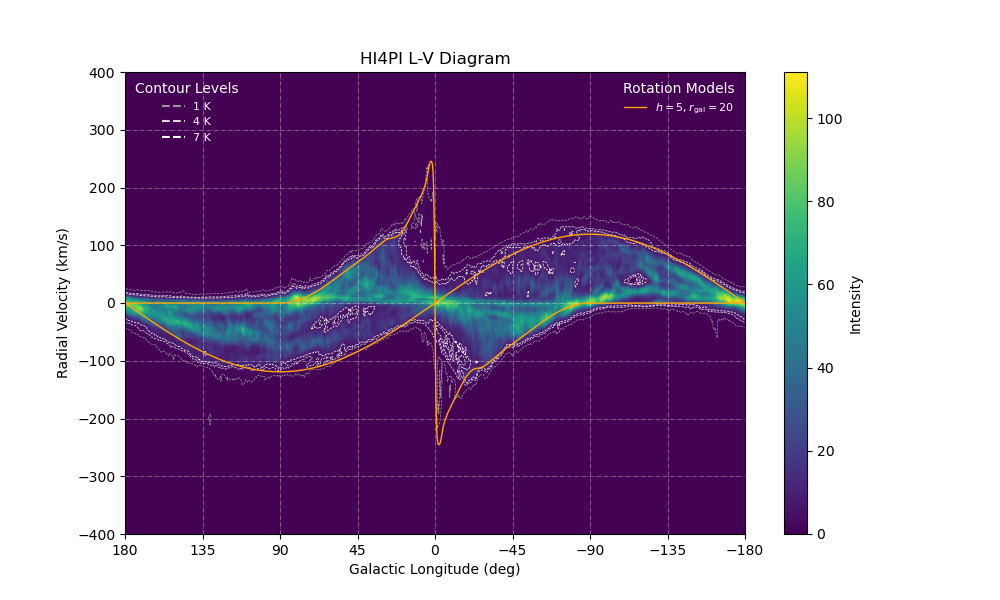

In [25]:
# Galaxy Rotation Model vs HI4PI L-V Diagram
from matplotlib.lines import Line2D

cmap = plt.get_cmap("Greys_r")
white_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "white_greys", cmap(np.linspace(0.5, 1.0, 256))
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    data,
    origin="lower",
    aspect="auto",
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],  # l_min
        wcs.pixel_to_world_values(nx - 1, 0)[0],  # l_max
        wcs.pixel_to_world_values(0, 0)[1] / 1000,  # v_min
        wcs.pixel_to_world_values(0, ny - 1)[1] / 1000,  # v_max
    ],
    norm=PowerNorm(gamma=1),  # 使用线性归一化
    cmap="viridis",  # 使用viridis色图
)

# 绘制等高线 - 使用color参数直接指定颜色
# 先计算每个级别的颜色
contour_levels = np.arange(1, 10, 3)
level_norm = (contour_levels - np.min(contour_levels)) / (
    np.max(contour_levels) - np.min(contour_levels)
)
level_colors = [white_cmap(val) for val in level_norm]

# 绘制等高线，指定颜色
contours = ax.contour(
    data,
    origin="lower",
    levels=contour_levels,
    colors=level_colors,  # 直接指定颜色列表
    linewidths=0.5,
    linestyles="dashed",
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],  # l_min
        wcs.pixel_to_world_values(nx - 1, 0)[0],  # l_max
        wcs.pixel_to_world_values(0, 0)[1] / 1000,  # v_min
        wcs.pixel_to_world_values(0, ny - 1)[1] / 1000,  # v_max
    ],
)

# 创建图例元素，使用相同的颜色
legend_elements = []
for level, color in zip(contour_levels, level_colors):
    legend_elements.append(
        Line2D([0], [0], color=color, lw=1.5, linestyle="dashed", label=f"{level} K")
    )

# 添加图例
legend1 = ax.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=8,
    labelcolor="white",
    framealpha=0.0,
    edgecolor="white",
    title="Contour Levels",
    handlelength=2,
)
legend1.get_title().set_color("white")
ax.add_artist(legend1)

ax.set_xlabel("Galactic Longitude (deg)")
ax.set_ylabel("Radial Velocity (km/s)")
plt.colorbar(im, ax=ax, label="Intensity")
plt.title("HI4PI L-V Diagram")

# 画L-V图
l_array = np.arange(-179.9, 180, 0.1)
v_max_arr1, v_min_arr1 = calc_v_dev(l_array, b=0, h=5, r_gal=20, model="poly")
ax.plot(l_array, v_max_arr1, color="orange", linewidth=1, label=r"$h=5, r_{\mathrm{gal}}=20$")
ax.plot(l_array, v_min_arr1, color="orange", linewidth=1)


legend2 = ax.legend(
    loc="upper right",
    fontsize=8,
    labelcolor="white",
    framealpha=0.0,
    edgecolor="white",
    title="Rotation Models",
)
legend2.get_title().set_color("white")

# 设置网格
ax.grid(ls="-.", color="white", alpha=0.5, linewidth=0.5)

# 设置网格线的位置
# 横坐标：-180到180，每45一个
ax.set_xticks(np.arange(-180, 181, 45))
# 纵坐标：-400到400，每100一个
ax.set_yticks(np.arange(-400, 401, 100))

# 设置坐标轴范围（确保显示完整的网格）
ax.set_xlim(-180, 180)
ax.set_ylim(-400, 400)
ax.invert_xaxis()

plt.show()

In [19]:
# Generate l and b arrays
l = np.arange(0, 360, 0.1)
b = np.arange(-90, 90.1, 0.1)

# Create meshgrids for l and b
L, B = np.meshgrid(l, b)  # L: (3600, 1801), B: (3600, 1801)

# Vectorized call to calc_v_dev (now supports array inputs)
v_max_arr, v_min_arr = calc_v_dev(L, B, h=5, r_gal=20, model="univ")

In [20]:
# 创建WCS头信息，NAXIS=3
hdr = fits.Header()
hdr["NAXIS"] = 2
hdr["NAXIS1"] = v_max_arr.shape[1]  # 3601 (l)
hdr["NAXIS2"] = v_max_arr.shape[0]  # 1801 (b)

# WCS信息
hdr["CTYPE1"] = "GLON"
hdr["CRVAL1"] = 0.0
hdr["CRPIX1"] = 1.0
hdr["CDELT1"] = 0.1

hdr["CTYPE2"] = "GLAT"
hdr["CRVAL2"] = -90.0
hdr["CRPIX2"] = 1.0
hdr["CDELT2"] = 0.1

hdr["BUNIT"] = "km/s"
hdr

NAXIS   =                    2                                                  
NAXIS1  =                 3600                                                  
NAXIS2  =                 1801                                                  
CTYPE1  = 'GLON    '                                                            
CRVAL1  =                  0.0                                                  
CRPIX1  =                  1.0                                                  
CDELT1  =                  0.1                                                  
CTYPE2  = 'GLAT    '                                                            
CRVAL2  =                -90.0                                                  
CRPIX2  =                  1.0                                                  
CDELT2  =                  0.1                                                  
BUNIT   = 'km/s    '                                                            

In [21]:
hdu1 = fits.PrimaryHDU(v_max_arr, header=hdr)
hdu1.writeto("galaxy_rotation_model_+.fits", overwrite=True)
hdu2 = fits.PrimaryHDU(v_min_arr, header=hdr)
hdu2.writeto("galaxy_rotation_model_-.fits", overwrite=True)

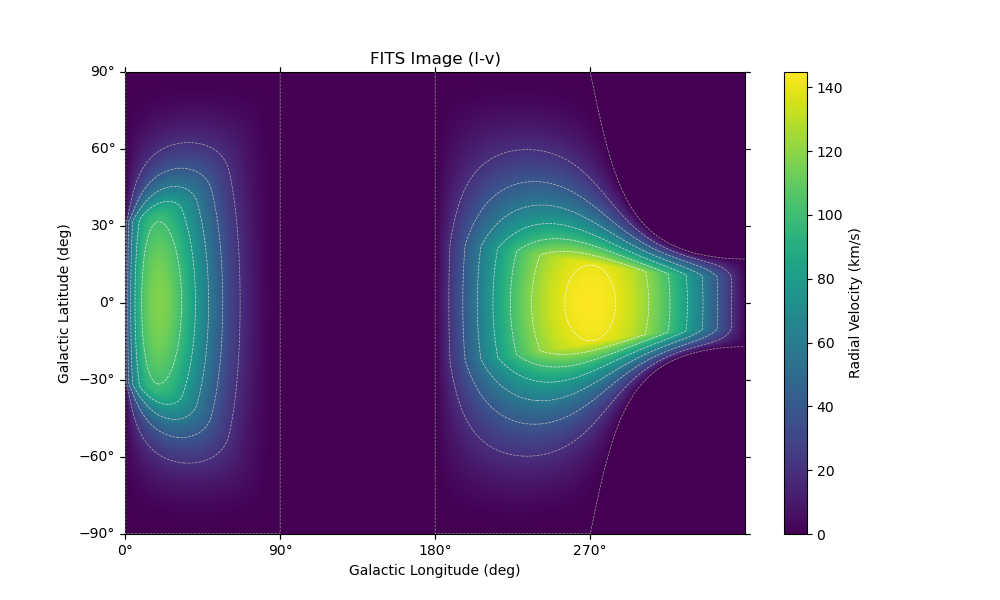

In [22]:
filename1 = "galaxy_rotation_model_+.fits"

# 打开FITS文件
with fits.open(filename1) as hdul:
    data1 = hdul[0].data
    header1 = hdul[0].header

wcs1 = WCS(header1)

# 画图
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": wcs1})
im = ax.imshow(
    data1,
    origin="lower",
    aspect="auto",
    norm=PowerNorm(gamma=1),  # 使用线性归一化
    cmap="viridis",  # 使用viridis色图
)
ax.contour(data1, origin="lower", cmap=white_cmap, linewidths=0.5, linestyles="dashed")

ax.set_xlabel("Galactic Longitude (deg)")
ax.set_ylabel("Galactic Latitude (deg)")
plt.colorbar(im, ax=ax, label="Radial Velocity (km/s)")
plt.title("FITS Image (l-v)")

plt.show()

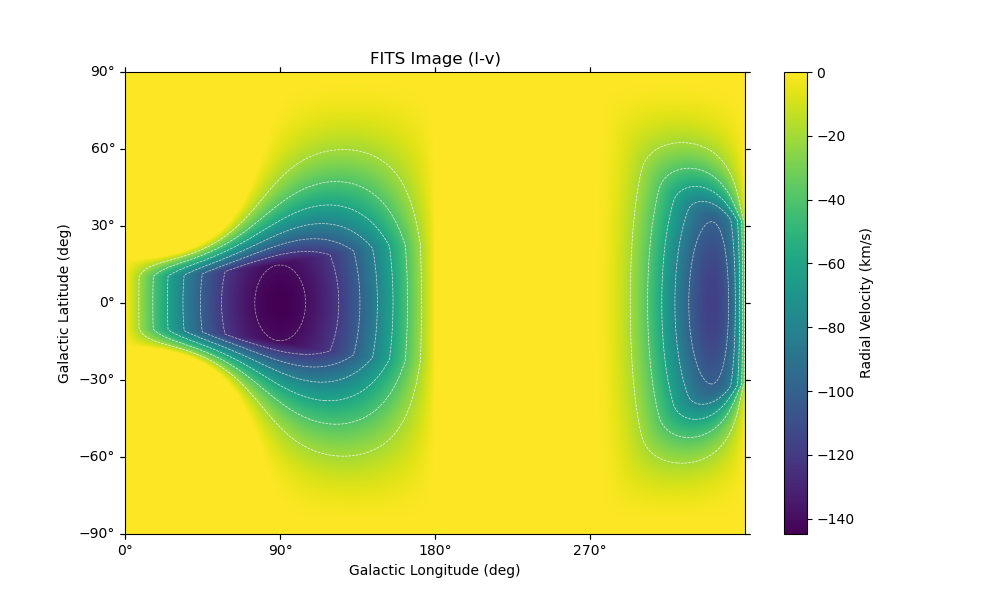

In [23]:
filename2 = "galaxy_rotation_model_-.fits"

# 打开FITS文件
with fits.open(filename2) as hdul:
    data2 = hdul[0].data
    header2 = hdul[0].header

wcs2 = WCS(header2)

# 画图
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": wcs2})
im = ax.imshow(
    data2,
    origin="lower",
    aspect="auto",
    norm=PowerNorm(gamma=1),  # 使用线性归一化
    cmap="viridis",  # 使用viridis色图
)
ax.contour(data2, origin="lower", cmap=white_cmap, linewidths=0.5, linestyles="dashed")

ax.set_xlabel("Galactic Longitude (deg)")
ax.set_ylabel("Galactic Latitude (deg)")
plt.colorbar(im, ax=ax, label="Radial Velocity (km/s)")
plt.title("FITS Image (l-v)")

plt.show()